In [ ]:
from google.colab import files
files.upload()

Saving gnr638-assignment2.zip to gnr638-assignment2.zip


{'gnr638-assignment2.zip': b'PK\x03\x04\n\x00\x00\x00\x00\x00ydf\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x13\x00\t\x00gnr638-assignment2/UT\x05\x00\x01\xa7:\xabiPK\x03\x04\n\x00\x00\x00\x00\x00ydf\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1b\x00\t\x00gnr638-assignment2/configs/UT\x05\x00\x01\xa7:\xabiPK\x03\x04\n\x00\x00\x00\x08\x00ydf\\\xf07\xd0X\x91\x01\x00\x00\xe3\x03\x00\x00-\x00\t\x00gnr638-assignment2/configs/model_configs.yamlUT\x05\x00\x01\xa7:\xabiuS\xdbn\x830\x0c}\xefW\xa0>O\x15\xb0n\x0f\xfd\x95i\x8aLpi\xd4\\\x90\x1dTu_?\'\x90\xaat\xec\x05%\xc7\xe7\xd8>vp\xa1G\xcb\xa7]U\x11\xb2\xc7\xf8Q\xa7sUE\xe3\x9c\xf2\xe0\xf0\xf4\x08d|$\x8c\x04\xc6c\x7f\xaa"M(`\x8f\x9eQ\x18M\xdb\xfc\xd1>\xc5\xfe\x93\xe3\xf9l\xb4A\x1f\x85\xa6\xba\xbf\xe5_\xe2\xdbiv\xf9j\xfc\x90\xe4\x8c\t?\xb6r\xec \xea\x8bb\xf3#\x89>\x8f\x02\xf8\xc9\xa9[\xa0+\x12\x0be\x01\xb4\x05f\x14\xe0=\xa57nX\x14m\x9b\x18a\x94n\xe4N\xa7\nzp\x82X9\xd6\x87\xbaN\x9enh\x86KT=j\xb8\xcf\xa8\xc0;\xd6\xe8\x81L\xc8\x93\xb5\xd

In [ ]:
!unzip gnr638-assignment2.zip
%cd gnr638-assignment2

Archive:  gnr638-assignment2.zip
70724621c0b8490e25c4f86afc24bcf6af9ed0fb
   creating: gnr638-assignment2/
   creating: gnr638-assignment2/configs/
  inflating: gnr638-assignment2/configs/model_configs.yaml  
   creating: gnr638-assignment2/data/
  inflating: gnr638-assignment2/data/dataset_instructions.md  
   creating: gnr638-assignment2/models/
  inflating: gnr638-assignment2/models/load_models.py  
  inflating: gnr638-assignment2/requirements.txt  
  inflating: gnr638-assignment2/scenario_1.ipynb  
  inflating: gnr638-assignment2/scenerio_5.ipynb  
   creating: gnr638-assignment2/utils/
  inflating: gnr638-assignment2/utils/corruption.py  
  inflating: gnr638-assignment2/utils/dataset_loader.py  
  inflating: gnr638-assignment2/utils/metrics.py  
/content/gnr638-assignment2


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=d0342448e41593dba17a570e462d878a8899d1b20db620e24068033d4fff0f40
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=17bc212b807a92c84b21a0de05a582eaeb6d2c5a701bf6a83805fc2186da6b41
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown

In [ ]:
!gdown 1yBuXnJdjlTmVYw3fFovROyxaMP8XU815 -O Assignment2_data_gnr638.zip

Downloading...
From (original): https://drive.google.com/uc?id=1yBuXnJdjlTmVYw3fFovROyxaMP8XU815
From (redirected): https://drive.google.com/uc?id=1yBuXnJdjlTmVYw3fFovROyxaMP8XU815&confirm=t&uuid=b58f0482-06b9-4687-ac32-1f54e1869b96
To: /content/gnr638-assignment2/Assignment2_data_gnr638.zip
100% 1.83G/1.83G [00:27<00:00, 65.9MB/s]


In [ ]:
# !unzip "/content/gnr638-assignment2/Assignment2_data_gnr638.zip" -d /content/

In [ ]:
DATA_DIR = "/content/train_data"

In [ ]:
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from models.load_models import (
    load_model,
    freeze_backbone,
    unfreeze_last_block,
    count_parameters,
    compute_efficiency_metrics
)

from utils.dataset_loader import get_dataloaders
from utils.metrics import compute_accuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
CONFIG_PATH = "configs/model_configs.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

models_cfg = config["models"]
train_cfg = config["training"]
scenario_cfg = config["scenarios"]["fine_tuning"]

print("Models:", list(models_cfg.keys()))
print("Epochs:", scenario_cfg["epochs"])

Models: ['resnet50', 'densenet121', 'efficientnet_b0']
Epochs: 30


In [ ]:
train_loader, val_loader, classes = get_dataloaders(
    DATA_DIR,
    batch_size=train_cfg["batch_size"],
    num_workers=train_cfg["num_workers"],
    seed=train_cfg["seed"],
    img_size=train_cfg["img_size"],
    augment=True
)

num_classes = len(classes)
print("Classes:", num_classes)

[Dataset] Train: 5594 | Val: 1399 | Fraction used: 1.0
Classes: 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=train_cfg["weight_decay"]
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    grad_norms = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        running_acc = 0

        for images, labels in tqdm(train_loader, leave=False):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2

            grad_norms.append(total_norm ** 0.5)

            optimizer.step()

            running_loss += loss.item()
            running_acc += compute_accuracy(outputs, labels)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(running_acc / len(train_loader))

        model.eval()
        val_loss = 0
        val_acc = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_acc += compute_accuracy(outputs, labels)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_acc / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs} | Train Acc {train_accs[-1]:.4f} | Val Acc {val_accs[-1]:.4f}")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "grad_norms": grad_norms
    }

In [ ]:
strategies = [
    "linear_probe",
    "last_block",
    "full_finetune"
]

In [ ]:
import os

CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Saving models to:", CHECKPOINT_DIR)

Saving models to: /content/checkpoints


In [ ]:
import os
import pandas as pd

RESULTS_FILE = "/content/scenario2_results.csv"

# Load previous results if file exists
if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE)
    results = results_df.to_dict("records")
    print("Loaded existing results:", len(results))
else:
    results = []
    print("Starting fresh results list")

Starting fresh results list


In [ ]:
model_name = "resnet50"

print("\n========================")
print("Model:", model_name)

for strategy in strategies:

    print("\nStrategy:", strategy)

    model = load_model(model_name, num_classes).to(device)

    if strategy == "linear_probe":
        model = freeze_backbone(model)

    elif strategy == "last_block":
        model = unfreeze_last_block(model, model_name)

    elif strategy == "full_finetune":
        for p in model.parameters():
            p.requires_grad = True

    total_params, trainable_params = count_parameters(model)
    percent_unfrozen = trainable_params / total_params * 100

    print("Trainable %:", percent_unfrozen)

    efficiency = compute_efficiency_metrics(model)

    history = train_model(
        model,
        train_loader,
        val_loader,
        scenario_cfg["epochs"],
        train_cfg["lr"]
    )

    save_path = f"{CHECKPOINT_DIR}/{model_name}_{strategy}.pth"
    torch.save(model.state_dict(), save_path)

    print("Model saved:", save_path)

    best_val_acc = max(history["val_acc"])

    results.append({
        "model": model_name,
        "strategy": strategy,
        "trainable_params": trainable_params,
        "percent_unfrozen": percent_unfrozen,
        "best_val_acc": best_val_acc,
        **efficiency
    })

    # SAVE RESULTS AFTER EACH STRATEGY
    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

    print("Results saved")


Model: resnet50

Strategy: linear_probe


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Trainable %: 0.2608031344913439



  Parameters : 23.57 M
  MACs       : 4.13 G
  FLOPs      : 4.11 G



...

Epoch 26/30 | Train Acc 0.9783 | Val Acc 0.8838


Epoch 27/30 | Train Acc 0.9702 | Val Acc 0.9293


Epoch 28/30 | Train Acc 0.9799 | Val Acc 0.9459


Epoch 29/30 | Train Acc 0.9726 | Val Acc 0.9143


Epoch 30/30 | Train Acc 0.9732 | Val Acc 0.8775
Model saved: /content/checkpoints/resnet50_full_finetune.pth
Results saved


In [ ]:
import pandas as pd
pd.read_csv(RESULTS_FILE)

,model,strategy,trainable_params,percent_unfrozen,best_val_acc,params_M,macs_G,flops_G
0,resnet50,linear_probe,61470,0.260803,0.884595,23.57,4.13,4.11
1,resnet50,last_block,15026206,63.752751,0.950168,23.57,4.13,4.11
2,resnet50,full_finetune,23569502,100.000000,0.945907,23.57,4.13,4.11


In [ ]:
!cp /content/scenario2_results.csv /content/drive/MyDrive/

In [ ]:
model_name = "densenet121"

print("\n========================")
print("Model:", model_name)

for strategy in strategies:

    print("\nStrategy:", strategy)

    model = load_model(model_name, num_classes).to(device)

    if strategy == "linear_probe":
        model = freeze_backbone(model)

    elif strategy == "last_block":
        model = unfreeze_last_block(model, model_name)

    elif strategy == "full_finetune":
        for p in model.parameters():
            p.requires_grad = True

    total_params, trainable_params = count_parameters(model)
    percent_unfrozen = trainable_params / total_params * 100

    print("Trainable %:", percent_unfrozen)

    efficiency = compute_efficiency_metrics(model)

    history = train_model(
        model,
        train_loader,
        val_loader,
        scenario_cfg["epochs"],
        train_cfg["lr"]
    )

    save_path = f"{CHECKPOINT_DIR}/{model_name}_{strategy}.pth"
    torch.save(model.state_dict(), save_path)

    print("Model saved:", save_path)

    best_val_acc = max(history["val_acc"])

    results.append({
        "model": model_name,
        "strategy": strategy,
        "trainable_params": trainable_params,
        "percent_unfrozen": percent_unfrozen,
        "best_val_acc": best_val_acc,
        **efficiency
    })

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

    print("Results saved")


Model: densenet121

Strategy: linear_probe


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Trainable %: 0.4402538954953222



  Parameters : 6.90 M
  MACs       : 2.83 G
  FLOPs      : 2.86 G



  0%|          | 0/88 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch 26/30 | Train Acc 0.9749 | Val Acc 0.9213


Epoch 27/30 | Train Acc 0.9787 | Val Acc 0.9162


Epoch 28/30 | Train Acc 0.9822 | Val Acc 0.9412


Epoch 29/30 | Train Acc 0.9863 | Val Acc 0.9272


Epoch 30/30 | Train Acc 0.9877 | Val Acc 0.9185
Model saved: /content/checkpoints/densenet121_full_finetune.pth
Results saved


In [ ]:
import pandas as pd
pd.read_csv(RESULTS_FILE)

,model,strategy,trainable_params,percent_unfrozen,best_val_acc,params_M,macs_G,flops_G
0,resnet50,linear_probe,61470,0.260803,0.884595,23.57,4.13,4.11
1,resnet50,last_block,15026206,63.752751,0.950168,23.57,4.13,4.11
2,resnet50,full_finetune,23569502,100.000000,0.945907,23.57,4.13,4.11
3,densenet121,linear_probe,30750,0.440254,0.914540,6.90,2.83,2.86
4,densenet121,last_block,2188830,31.337917,0.950168,6.90,2.83,2.86
5,densenet121,full_finetune,6984606,100.000000,0.941180,6.90,2.83,2.86


In [ ]:
!cp /content/scenario2_results.csv /content/drive/MyDrive/

In [ ]:
model_name = "efficientnet_b0"

print("\n========================")
print("Model:", model_name)

for strategy in strategies:

    print("\nStrategy:", strategy)

    model = load_model(model_name, num_classes).to(device)

    if strategy == "linear_probe":
        model = freeze_backbone(model)

    elif strategy == "last_block":
        model = unfreeze_last_block(model, model_name)

    elif strategy == "full_finetune":
        for p in model.parameters():
            p.requires_grad = True

    total_params, trainable_params = count_parameters(model)
    percent_unfrozen = trainable_params / total_params * 100

    print("Trainable %:", percent_unfrozen)

    efficiency = compute_efficiency_metrics(model)

    history = train_model(
        model,
        train_loader,
        val_loader,
        scenario_cfg["epochs"],
        train_cfg["lr"]
    )

    save_path = f"{CHECKPOINT_DIR}/{model_name}_{strategy}.pth"
    torch.save(model.state_dict(), save_path)

    print("Model saved:", save_path)

    best_val_acc = max(history["val_acc"])

    results.append({
        "model": model_name,
        "strategy": strategy,
        "trainable_params": trainable_params,
        "percent_unfrozen": percent_unfrozen,
        "best_val_acc": best_val_acc,
        **efficiency
    })

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

    print("Results saved")


Model: efficientnet_b0

Strategy: linear_probe


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Trainable %: 11.07346604455091



  Parameters : 4.00 M
  MACs       : 0.38 G
  FLOPs      : 0.40 G



  0%|          | 0/88 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch 30/30 | Train Acc 0.9851 | Val Acc 0.9292
Model saved: /content/checkpoints/efficientnet_b0_last_block.pth
Results saved

Strategy: full_finetune
Trainable %: 100.0



  Parameters : 4.00 M
  MACs       : 0.38 G
  FLOPs      : 0.40 G



  0%|          | 0/88 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/30 | Train Acc 0.8086 | Val Acc 0.9150


 28%|██▊       | 25/88 [00:18<00:41,  1.52it/s]

In [ ]:
model_name = "efficientnet_b0"
strategy="full_finetune"
print("\n========================")
print("Model:", model_name)


print("\nStrategy:", strategy)

model = load_model(model_name, num_classes).to(device)

if strategy == "linear_probe":
    model = freeze_backbone(model)

elif strategy == "last_block":
    model = unfreeze_last_block(model, model_name)

elif strategy == "full_finetune":
    for p in model.parameters():
        p.requires_grad = True

total_params, trainable_params = count_parameters(model)
percent_unfrozen = trainable_params / total_params * 100
print(trainable_params)
print("Trainable %:", percent_unfrozen)

efficiency = compute_efficiency_metrics(model)

history = train_model(
    model,
    train_loader,
    val_loader,
    scenario_cfg["epochs"],
    train_cfg["lr"]
)

save_path = f"{CHECKPOINT_DIR}/{model_name}_{strategy}.pth"
torch.save(model.state_dict(), save_path)

print("Model saved:", save_path)

best_val_acc = max(history["val_acc"])
print(best_val_acc)
results.append({
    "model": model_name,
    "strategy": strategy,
    "trainable_params": trainable_params,
    "percent_unfrozen": percent_unfrozen,
    "best_val_acc": best_val_acc,
    **efficiency
})

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_FILE, index=False)

print("Results saved")


Model: efficientnet_b0

Strategy: full_finetune
4045978
Trainable %: 100.0



  Parameters : 4.00 M
  MACs       : 0.38 G
  FLOPs      : 0.40 G



  0%|          | 0/88 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/30 | Train Acc 0.7950 | Val Acc 0.8892


Epoch 2/30 | Train Acc 0.9269 | Val Acc 0.9185


...

Epoch 26/30 | Train Acc 0.9775 | Val Acc 0.9459


Epoch 27/30 | Train Acc 0.9843 | Val Acc 0.9394


Epoch 28/30 | Train Acc 0.9838 | Val Acc 0.9328


Epoch 29/30 | Train Acc 0.9815 | Val Acc 0.9306


Epoch 30/30 | Train Acc 0.9769 | Val Acc 0.9343
Model saved: /content/checkpoints/efficientnet_b0_full_finetune.pth
0.9528925619834712
Results saved


In [ ]:
import pandas as pd
pd.read_csv(RESULTS_FILE)

In [ ]:
!cp /content/scenario2_results.csv /content/drive/MyDrive/

In [ ]:
!cp -r /content/checkpoints /content/drive/MyDrive/

In [ ]:
results_df = pd.DataFrame(results)
results_df

In [ ]:
results_df.to_csv("scenario2_results.csv", index=False)

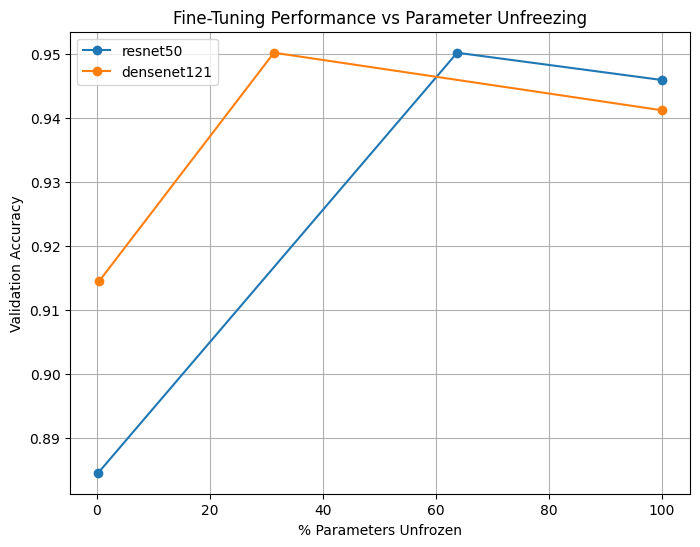

In [ ]:
plt.figure(figsize=(8,6))

for model_name in results_df["model"].unique():

    subset = results_df[results_df["model"] == model_name]

    plt.plot(
        subset["percent_unfrozen"],
        subset["best_val_acc"],
        marker="o",
        label=model_name
    )

plt.xlabel("% Parameters Unfrozen")
plt.ylabel("Validation Accuracy")
plt.title("Fine-Tuning Performance vs Parameter Unfreezing")
plt.legend()
plt.grid(True)
plt.show()

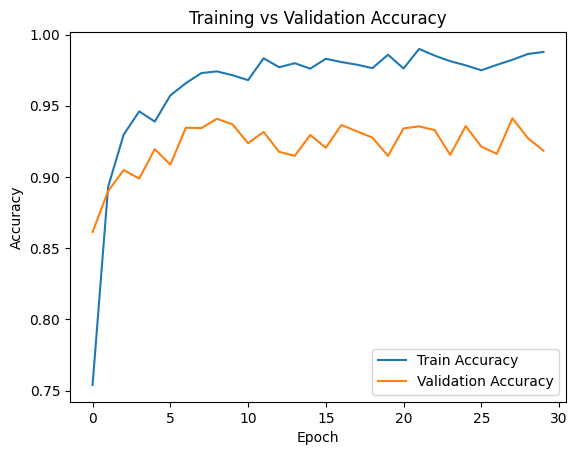

In [ ]:
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

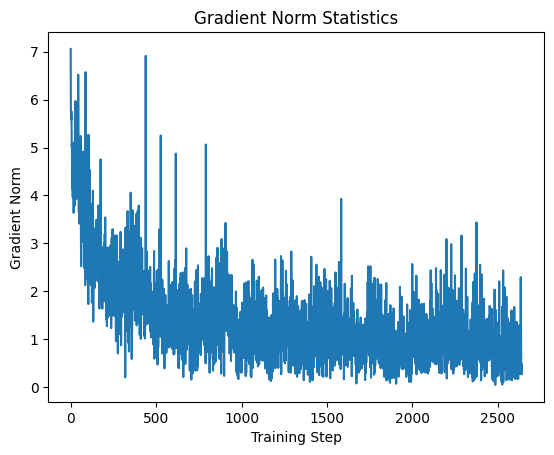

In [ ]:
plt.plot(history["grad_norms"])
plt.title("Gradient Norm Statistics")
plt.xlabel("Training Step")
plt.ylabel("Gradient Norm")
plt.show()

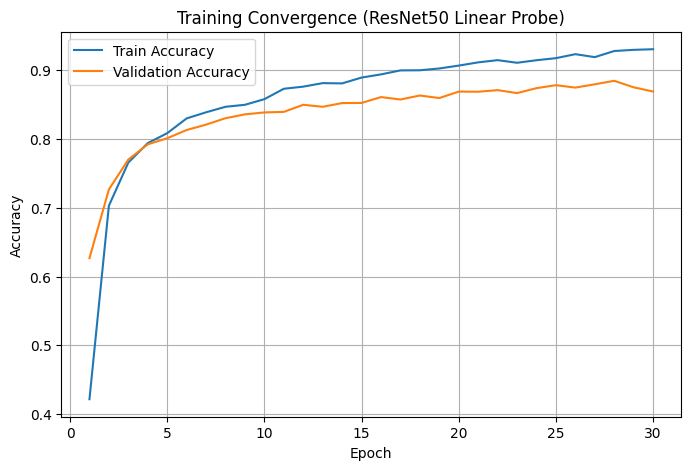

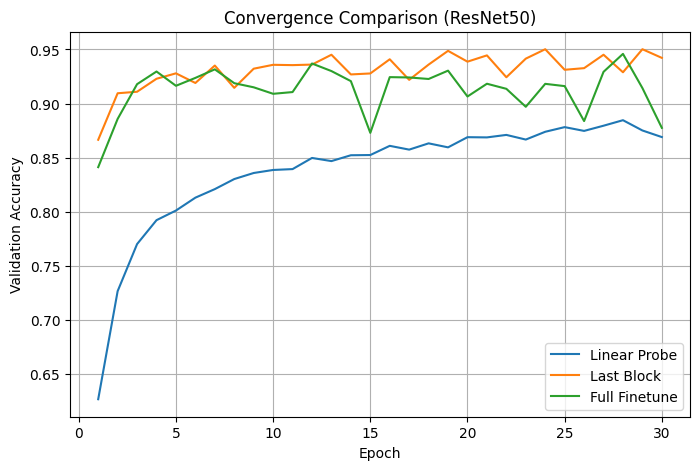

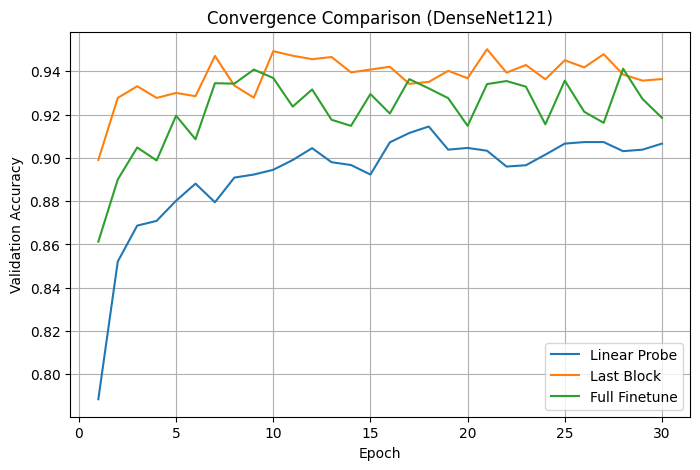

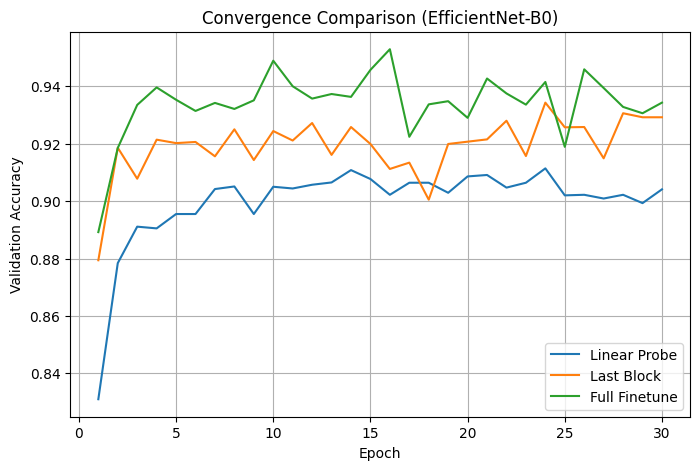

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1,31))

# =========================
# RESNET50
# =========================

resnet_linear_train = [
0.4216,0.7030,0.7657,0.7940,0.8084,0.8299,0.8388,0.8468,0.8497,0.8579,
0.8730,0.8761,0.8812,0.8808,0.8893,0.8939,0.8997,0.8999,0.9025,0.9067,
0.9114,0.9146,0.9108,0.9145,0.9175,0.9233,0.9190,0.9279,0.9296,0.9305
]

resnet_linear_val = [
0.6267,0.7266,0.7701,0.7922,0.8011,0.8130,0.8209,0.8302,0.8358,0.8386,
0.8394,0.8497,0.8468,0.8522,0.8524,0.8609,0.8574,0.8632,0.8595,0.8689,
0.8687,0.8710,0.8667,0.8739,0.8782,0.8747,0.8795,0.8846,0.8751,0.8690
]

resnet_last_val = [
0.8665,0.9095,0.9109,0.9229,0.9279,0.9190,0.9351,0.9145,0.9322,0.9358,
0.9355,0.9360,0.9451,0.9269,0.9278,0.9409,0.9219,0.9360,0.9487,0.9387,
0.9445,0.9243,0.9415,0.9502,0.9312,0.9327,0.9451,0.9289,0.9502,0.9422
]

resnet_full_val = [
0.8412,0.8858,0.9179,0.9296,0.9164,0.9237,0.9316,0.9188,0.9150,0.9090,
0.9106,0.9370,0.9300,0.9207,0.8729,0.9244,0.9241,0.9227,0.9304,0.9065,
0.9183,0.9136,0.8970,0.9182,0.9161,0.8838,0.9293,0.9459,0.9143,0.8775
]

# =========================
# DENSENET121
# =========================

dense_linear_val = [
0.7885,0.8521,0.8687,0.8709,0.8802,0.8881,0.8795,0.8909,0.8923,0.8945,
0.8990,0.9045,0.8980,0.8967,0.8923,0.9072,0.9115,0.9145,0.9038,0.9046,
0.9033,0.8960,0.8966,0.9015,0.9066,0.9073,0.9073,0.9031,0.9038,0.9066
]

dense_last_val = [
0.8990,0.9277,0.9331,0.9277,0.9300,0.9285,0.9471,0.9334,0.9278,0.9493,
0.9472,0.9456,0.9466,0.9395,0.9408,0.9421,0.9342,0.9351,0.9402,0.9368,
0.9502,0.9394,0.9429,0.9363,0.9451,0.9418,0.9479,0.9385,0.9357,0.9364
]

dense_full_val = [
0.8613,0.8900,0.9048,0.8988,0.9195,0.9086,0.9345,0.9343,0.9408,0.9369,
0.9237,0.9316,0.9176,0.9148,0.9295,0.9205,0.9364,0.9321,0.9276,0.9148,
0.9341,0.9355,0.9329,0.9155,0.9357,0.9213,0.9162,0.9412,0.9272,0.9185
]

# =========================
# EFFICIENTNET
# =========================

eff_linear_val = [
0.8310,0.8784,0.8911,0.8905,0.8955,0.8955,0.9042,0.9051,0.8955,0.9050,
0.9044,0.9057,0.9065,0.9108,0.9077,0.9022,0.9064,0.9064,0.9029,0.9086,
0.9091,0.9047,0.9064,0.9114,0.9020,0.9022,0.9009,0.9022,0.8993,0.9041
]

eff_last_val = [
0.8794,0.9186,0.9078,0.9214,0.9202,0.9206,0.9156,0.9250,0.9143,0.9244,
0.9211,0.9272,0.9161,0.9258,0.9199,0.9112,0.9134,0.9005,0.9199,0.9207,
0.9215,0.9280,0.9157,0.9343,0.9257,0.9258,0.9149,0.9306,0.9292,0.9292
]

eff_full_val = [
0.8892,0.9185,0.9335,0.9396,0.9353,0.9314,0.9342,0.9321,0.9351,0.9489,
0.9400,0.9357,0.9373,0.9363,0.9457,0.9529,0.9224,0.9337,0.9348,0.9290,
0.9427,0.9375,0.9336,0.9415,0.9189,0.9459,0.9394,0.9328,0.9306,0.9343
]

# =========================
# Plot 1: Training vs Validation
# =========================

plt.figure(figsize=(8,5))

plt.plot(epochs, resnet_linear_train, label="Train Accuracy")
plt.plot(epochs, resnet_linear_val, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Convergence (ResNet50 Linear Probe)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Plot 2: Convergence Comparison (ResNet50)
# =========================

plt.figure(figsize=(8,5))

plt.plot(epochs, resnet_linear_val, label="Linear Probe")
plt.plot(epochs, resnet_last_val, label="Last Block")
plt.plot(epochs, resnet_full_val, label="Full Finetune")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (ResNet50)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Plot 3: Convergence Comparison (DenseNet121)
# =========================

plt.figure(figsize=(8,5))

plt.plot(epochs, dense_linear_val, label="Linear Probe")
plt.plot(epochs, dense_last_val, label="Last Block")
plt.plot(epochs, dense_full_val, label="Full Finetune")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (DenseNet121)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Plot 4: Convergence Comparison (EfficientNet-B0)
# =========================

plt.figure(figsize=(8,5))

plt.plot(epochs, eff_linear_val, label="Linear Probe")
plt.plot(epochs, eff_last_val, label="Last Block")
plt.plot(epochs, eff_full_val, label="Full Finetune")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (EfficientNet-B0)")
plt.legend()
plt.grid(True)
plt.show()

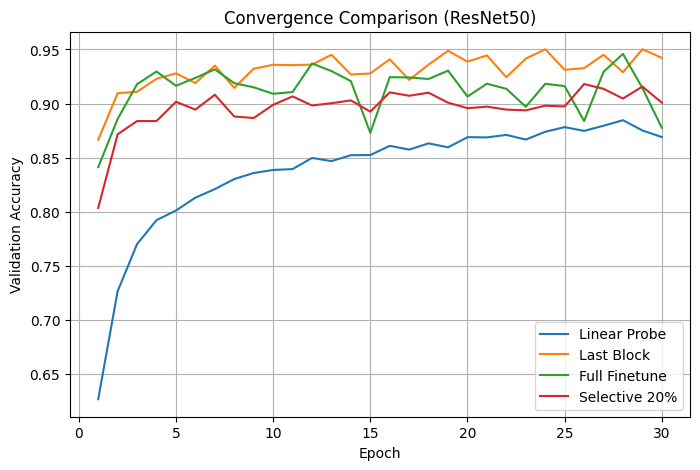

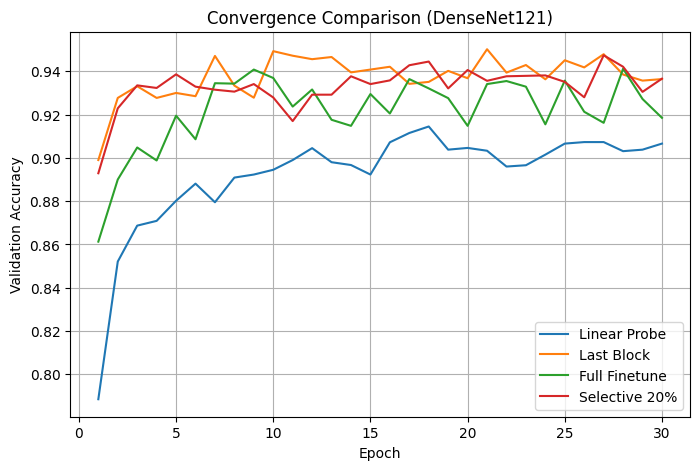

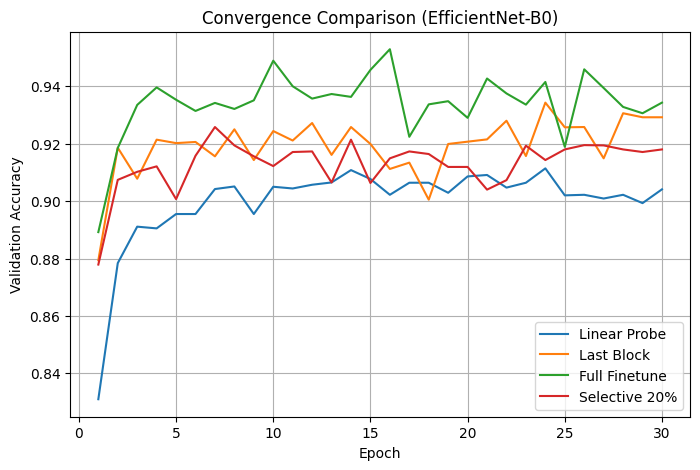

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1,31))

# =====================================
# RESNET50
# =====================================

resnet_linear = [
0.6267,0.7266,0.7701,0.7922,0.8011,0.8130,0.8209,0.8302,0.8358,0.8386,
0.8394,0.8497,0.8468,0.8522,0.8524,0.8609,0.8574,0.8632,0.8595,0.8689,
0.8687,0.8710,0.8667,0.8739,0.8782,0.8747,0.8795,0.8846,0.8751,0.8690
]

resnet_last = [
0.8665,0.9095,0.9109,0.9229,0.9279,0.9190,0.9351,0.9145,0.9322,0.9358,
0.9355,0.9360,0.9451,0.9269,0.9278,0.9409,0.9219,0.9360,0.9487,0.9387,
0.9445,0.9243,0.9415,0.9502,0.9312,0.9327,0.9451,0.9289,0.9502,0.9422
]

resnet_full = [
0.8412,0.8858,0.9179,0.9296,0.9164,0.9237,0.9316,0.9188,0.9150,0.9090,
0.9106,0.9370,0.9300,0.9207,0.8729,0.9244,0.9241,0.9227,0.9304,0.9065,
0.9183,0.9136,0.8970,0.9182,0.9161,0.8838,0.9293,0.9459,0.9143,0.8775
]

resnet_selective = [
0.8035,0.8716,0.8838,0.8838,0.9016,0.8944,0.9081,0.8880,0.8866,0.8988,
0.9066,0.8982,0.9003,0.9029,0.8925,0.9103,0.9072,0.9100,0.9008,0.8957,
0.8971,0.8944,0.8937,0.8980,0.8973,0.9180,0.9136,0.9046,0.9157,0.9008
]

plt.figure(figsize=(8,5))

plt.plot(epochs, resnet_linear, label="Linear Probe")
plt.plot(epochs, resnet_last, label="Last Block")
plt.plot(epochs, resnet_full, label="Full Finetune")
plt.plot(epochs, resnet_selective, label="Selective 20%")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (ResNet50)")
plt.legend()
plt.grid(True)
plt.show()


# =====================================
# DENSENET121
# =====================================

dense_linear = [
0.7885,0.8521,0.8687,0.8709,0.8802,0.8881,0.8795,0.8909,0.8923,0.8945,
0.8990,0.9045,0.8980,0.8967,0.8923,0.9072,0.9115,0.9145,0.9038,0.9046,
0.9033,0.8960,0.8966,0.9015,0.9066,0.9073,0.9073,0.9031,0.9038,0.9066
]

dense_last = [
0.8990,0.9277,0.9331,0.9277,0.9300,0.9285,0.9471,0.9334,0.9278,0.9493,
0.9472,0.9456,0.9466,0.9395,0.9408,0.9421,0.9342,0.9351,0.9402,0.9368,
0.9502,0.9394,0.9429,0.9363,0.9451,0.9418,0.9479,0.9385,0.9357,0.9364
]

dense_full = [
0.8613,0.8900,0.9048,0.8988,0.9195,0.9086,0.9345,0.9343,0.9408,0.9369,
0.9237,0.9316,0.9176,0.9148,0.9295,0.9205,0.9364,0.9321,0.9276,0.9148,
0.9341,0.9355,0.9329,0.9155,0.9357,0.9213,0.9162,0.9412,0.9272,0.9185
]

dense_selective = [
0.8929,0.9229,0.9335,0.9323,0.9386,0.9329,0.9315,0.9306,0.9341,0.9279,
0.9170,0.9292,0.9292,0.9377,0.9341,0.9358,0.9428,0.9445,0.9321,0.9406,
0.9356,0.9377,0.9379,0.9381,0.9351,0.9280,0.9474,0.9421,0.9305,0.9366
]

plt.figure(figsize=(8,5))

plt.plot(epochs, dense_linear, label="Linear Probe")
plt.plot(epochs, dense_last, label="Last Block")
plt.plot(epochs, dense_full, label="Full Finetune")
plt.plot(epochs, dense_selective, label="Selective 20%")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (DenseNet121)")
plt.legend()
plt.grid(True)
plt.show()


# =====================================
# EFFICIENTNET-B0
# =====================================

eff_linear = [
0.8310,0.8784,0.8911,0.8905,0.8955,0.8955,0.9042,0.9051,0.8955,0.9050,
0.9044,0.9057,0.9065,0.9108,0.9077,0.9022,0.9064,0.9064,0.9029,0.9086,
0.9091,0.9047,0.9064,0.9114,0.9020,0.9022,0.9009,0.9022,0.8993,0.9041
]

eff_last = [
0.8794,0.9186,0.9078,0.9214,0.9202,0.9206,0.9156,0.9250,0.9143,0.9244,
0.9211,0.9272,0.9161,0.9258,0.9199,0.9112,0.9134,0.9005,0.9199,0.9207,
0.9215,0.9280,0.9157,0.9343,0.9257,0.9258,0.9149,0.9306,0.9292,0.9292
]

eff_full = [
0.8892,0.9185,0.9335,0.9396,0.9353,0.9314,0.9342,0.9321,0.9351,0.9489,
0.9400,0.9357,0.9373,0.9363,0.9457,0.9529,0.9224,0.9337,0.9348,0.9290,
0.9427,0.9375,0.9336,0.9415,0.9189,0.9459,0.9394,0.9328,0.9306,0.9343
]

eff_selective = [
0.8779,0.9074,0.9102,0.9121,0.9007,0.9158,0.9258,0.9194,0.9156,0.9122,
0.9171,0.9173,0.9065,0.9214,0.9063,0.9149,0.9173,0.9164,0.9119,0.9119,
0.9040,0.9073,0.9193,0.9143,0.9180,0.9195,0.9194,0.9180,0.9171,0.9180
]

plt.figure(figsize=(8,5))

plt.plot(epochs, eff_linear, label="Linear Probe")
plt.plot(epochs, eff_last, label="Last Block")
plt.plot(epochs, eff_full, label="Full Finetune")
plt.plot(epochs, eff_selective, label="Selective 20%")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison (EfficientNet-B0)")
plt.legend()
plt.grid(True)
plt.show()

# Gradient Norm Analysis

[Dataset] Train: 5594 | Val: 1399 | Fraction used: 1.0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

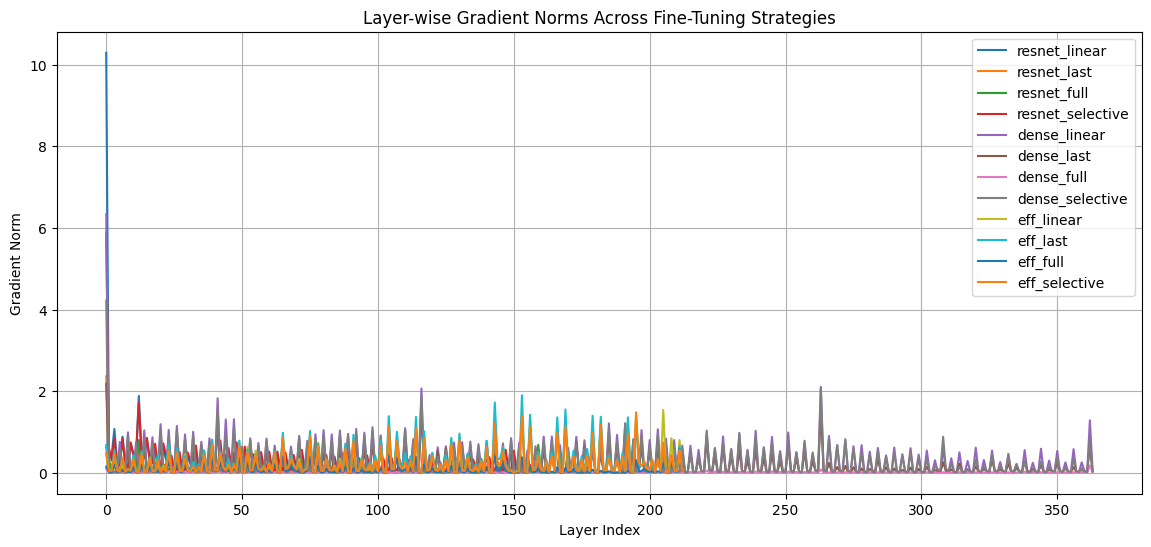

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from models.load_models import load_model
from utils.dataset_loader import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Dataset loader
# -----------------------------

train_loader, _, classes = get_dataloaders(
    DATA_DIR,
    batch_size=32,
    num_workers=2,
    img_size=224
)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

num_classes = len(classes)

# -----------------------------
# Model checkpoints
# -----------------------------

model_paths = {
    "resnet_linear": "/content/resnet50_linear_probe.pth",
    "resnet_last": "/content/resnet50_last_block.pth",
    "resnet_full": "/content/resnet50_full_finetune.pth",
    "resnet_selective":"/content/resnet50_selective20.pth",

    "dense_linear": "/content/densenet121_linear_probe.pth",
    "dense_last": "/content/densenet121_last_block.pth",
    "dense_full": "/content/densenet121_full_finetune.pth",
    "dense_selective":"/content/densenet121_selective20.pth",

    "eff_linear": "/content/efficientnet_b0_linear_probe.pth",
    "eff_last": "/content/efficientnet_b0_last_block.pth",
    "eff_full": "/content/efficientnet_b0_full_finetune.pth",
    "eff_selective": "/content/efficientnet_b0_selective20.pth"
}

model_arch = {
    "resnet_linear": "resnet50",
    "resnet_last": "resnet50",
    "resnet_full": "resnet50",
    "resnet_selective":"resnet50",

    "dense_linear": "densenet121",
    "dense_last": "densenet121",
    "dense_full": "densenet121",
    "dense_selective": "densenet121",

    "eff_linear": "efficientnet_b0",
    "eff_last": "efficientnet_b0",
    "eff_full": "efficientnet_b0",
    "eff_selective": "efficientnet_b0"
}

criterion = torch.nn.CrossEntropyLoss()

# -----------------------------
# Function to compute gradient norms
# -----------------------------

def compute_gradient_norms(model):

    model.train()
    model.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()

    grad_norms = []
    layer_names = []

    for name, param in model.named_parameters():

        if param.grad is not None:

            norm = param.grad.data.norm(2).item()
            grad_norms.append(norm)
            layer_names.append(name)

    return layer_names, grad_norms


# -----------------------------
# Plot gradient norms
# -----------------------------

plt.figure(figsize=(14,6))

for key in model_paths:

    model = load_model(model_arch[key], num_classes)
    model.load_state_dict(torch.load(model_paths[key], map_location=device))
    model = model.to(device)

    layers, norms = compute_gradient_norms(model)

    plt.plot(norms, label=key)

plt.xlabel("Layer Index")
plt.ylabel("Gradient Norm")
plt.title("Layer-wise Gradient Norms Across Fine-Tuning Strategies")
plt.legend()
plt.grid(True)

plt.show()

1️⃣ Linear Probing

Very large spike at the final layer only.

Interpretation:

In the linear probing strategy, gradients are concentrated almost entirely in the final classification layer, while the backbone layers receive negligible updates. This confirms that the pretrained feature extractor remains largely unchanged.

This matches transfer learning theory.

2️⃣ Last Block Fine-Tuning

Gradients appear mainly toward the end of the network.

Interpretation:

When fine-tuning the last block, gradients propagate primarily through deeper convolutional layers responsible for high-level semantic representations.

This explains why last_block achieved strong performance.

3️⃣ Full Fine-Tuning

Gradients appear across the entire network.

Interpretation:

Full fine-tuning distributes gradient updates across both early and deep layers, allowing the entire representation hierarchy to adapt to the aerial imagery dataset.

But also mention:

This sometimes introduces instability and mild overfitting.

4️⃣ Selective Tuning

Gradients appear in a subset of deeper layers.

Interpretation:

Selective tuning produces gradients concentrated in a subset of deeper layers, demonstrating that the automated parameter selection strategy successfully restricts updates to a limited portion of the network.

This validates Bonus Part 2.

# Selective filtering

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/gnr638_scenario2_models"
os.makedirs(SAVE_DIR, exist_ok=True)

RESULTS_FILE = os.path.join(SAVE_DIR, "scenario2_results.csv")

In [ ]:
def selective_unfreeze(model, target_ratio=0.20):

    total_params = sum(p.numel() for p in model.parameters())

    for p in model.parameters():
        p.requires_grad = False

    trainable = 0

    # unfreeze from deepest layers
    for name, param in reversed(list(model.named_parameters())):

        param.requires_grad = True
        trainable += param.numel()

        if trainable / total_params >= target_ratio:
            break

    return model

In [ ]:
import pandas as pd

if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE)
    results = results_df.to_dict("records")
    print("Loaded previous results")
else:
    results = []

In [ ]:
models = ["resnet50", "densenet121", "efficientnet_b0"]

for model_name in models:

    print("\n=======================")
    print("Selective tuning:", model_name)

    train_loader, val_loader, classes = get_dataloaders(
        DATA_DIR,
        batch_size=train_cfg["batch_size"],
        num_workers=train_cfg["num_workers"],
        seed=train_cfg["seed"],
        img_size=train_cfg["img_size"],
        augment=True
    )

    num_classes = len(classes)

    model = load_model(model_name, num_classes).to(device)

    # selective unfreeze (~20%)
    model = selective_unfreeze(model, target_ratio=0.20)

    total_params, trainable_params = count_parameters(model)

    percent_unfrozen = trainable_params / total_params * 100

    print("Trainable %:", percent_unfrozen)

    efficiency = compute_efficiency_metrics(model)

    history = train_model(
        model,
        train_loader,
        val_loader,
        scenario_cfg["epochs"],
        train_cfg["lr"]
    )

    best_val = max(history["val_acc"])

    # SAVE MODEL TO DRIVE
    save_path = os.path.join(
        SAVE_DIR,
        f"{model_name}_selective20.pth"
    )

    torch.save(model.state_dict(), save_path)

    print("Model saved:", save_path)

    results.append({
        "model": model_name,
        "strategy": "selective_20",
        "trainable_params": trainable_params,
        "percent_unfrozen": percent_unfrozen,
        "best_val_acc": best_val,
        **efficiency
    })

    # Save results after every run
    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

    print("Results saved")


Selective tuning: resnet50
[Dataset] Train: 5594 | Val: 1399 | Fraction used: 1.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Trainable %: 23.660805391645525



  Parameters : 23.57 M
  MACs       : 4.13 G
  FLOPs      : 4.11 G



...

Epoch 26/30 | Train Acc 0.9878 | Val Acc 0.9195


Epoch 27/30 | Train Acc 0.9864 | Val Acc 0.9194


Epoch 28/30 | Train Acc 0.9877 | Val Acc 0.9180


Epoch 29/30 | Train Acc 0.9888 | Val Acc 0.9171


Epoch 30/30 | Train Acc 0.9924 | Val Acc 0.9180
Model saved: /content/drive/MyDrive/gnr638_scenario2_models/efficientnet_b0_selective20.pth
Results saved


In [ ]:
df = pd.read_csv(RESULTS_FILE)

df["accuracy_per_param"] = df["best_val_acc"] / df["percent_unfrozen"]

df

,model,strategy,trainable_params,percent_unfrozen,best_val_acc,params_M,macs_G,flops_G,accuracy_per_param
0,resnet50,selective_20,5576734,23.660805,0.917975,23.57,4.13,4.11,0.038797
1,densenet121,selective_20,1414622,20.253426,0.947443,6.90,2.83,2.86,0.046779
2,efficientnet_b0,selective_20,819870,20.263827,0.925788,4.00,0.38,0.40,0.045687


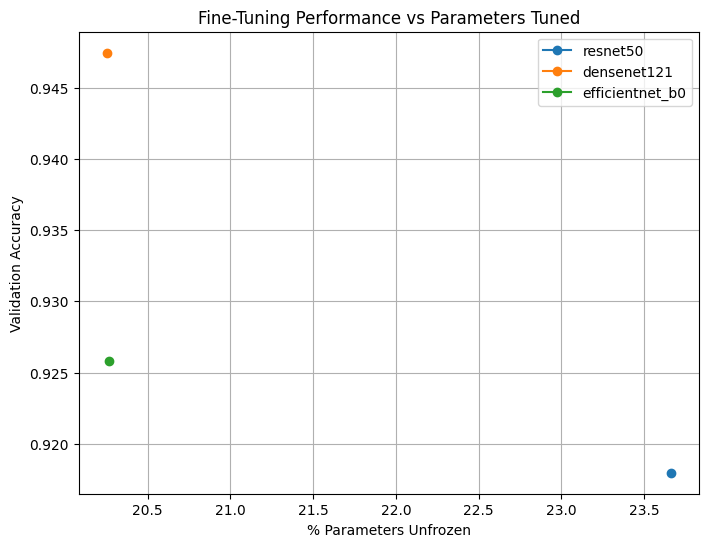

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model in df["model"].unique():

    subset = df[df["model"] == model]

    plt.plot(
        subset["percent_unfrozen"],
        subset["best_val_acc"],
        marker="o",
        label=model
    )

plt.xlabel("% Parameters Unfrozen")
plt.ylabel("Validation Accuracy")
plt.title("Fine-Tuning Performance vs Parameters Tuned")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy vs % Parameters Unfrozen

In [ ]:
df = pd.read_csv("scenario2_results.csv")
df

,model,strategy,trainable_params,percent_unfrozen,best_val_acc,params_M,macs_G,flops_G
0,resnet50,linear_probe,61470,0.260803,0.884595,23.57,4.13,4.11
1,resnet50,last_block,15026206,63.752751,0.950168,23.57,4.13,4.11
2,resnet50,full_finetune,23569502,100.000000,0.945907,23.57,4.13,4.11
3,densenet121,linear_probe,30750,0.440254,0.914540,6.90,2.83,2.86
4,densenet121,last_block,2188830,31.337917,0.950168,6.90,2.83,2.86
5,densenet121,full_finetune,6984606,100.000000,0.941180,6.90,2.83,2.86
6,efficientnet_b0,linear_probe,448030,11.073466,0.911351,4.00,0.38,0.40
7,efficientnet_b0,last_block,1165262,28.800500,0.934300,4.00,0.38,0.40
8,efficientnet_b0,full_finetune,4045978,100.000000,0.952890,4.00,0.38,0.40
9,resnet50,selective_20,5576734,23.660805,0.917975,23.57,4.13,4.11


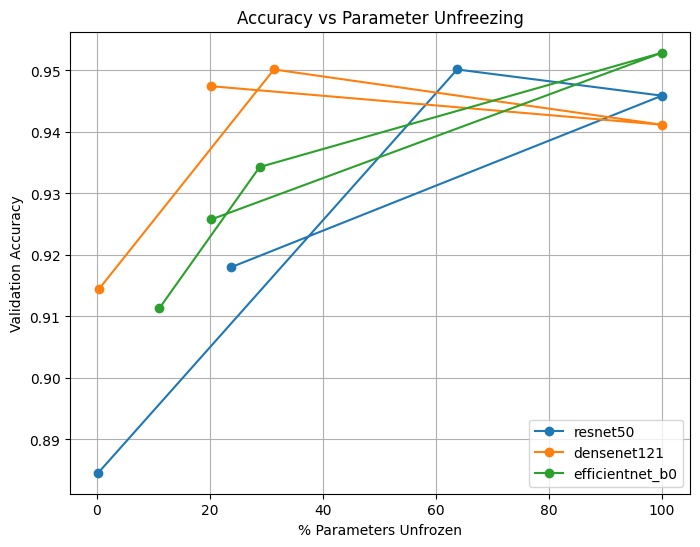

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



plt.figure(figsize=(8,6))

for model in df["model"].unique():

    subset = df[df["model"] == model]

    plt.plot(
        subset["percent_unfrozen"],
        subset["best_val_acc"],
        marker='o',
        label=model
    )

plt.xlabel("% Parameters Unfrozen")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy vs Parameter Unfreezing")
plt.legend()
plt.grid(True)
plt.show()

# Strategy vs Accuracy

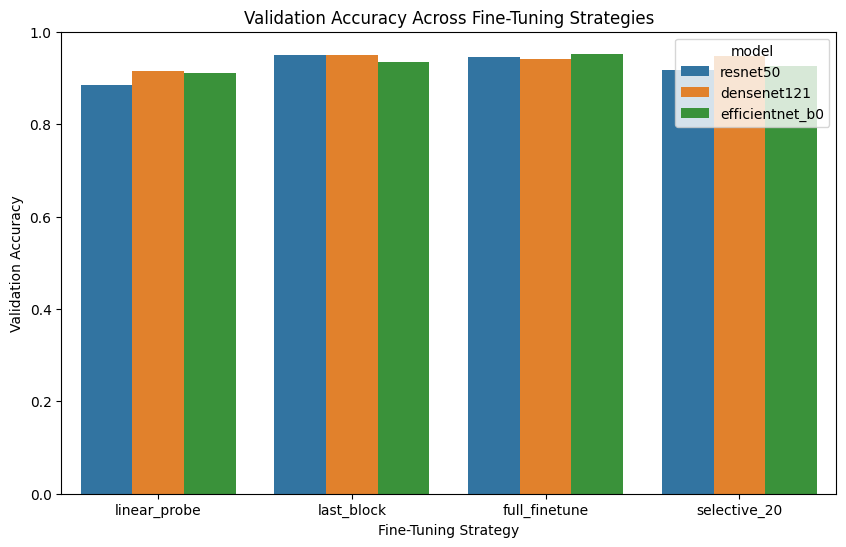

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="strategy",
    y="best_val_acc",
    hue="model"
)

plt.title("Validation Accuracy Across Fine-Tuning Strategies")
plt.ylabel("Validation Accuracy")
plt.xlabel("Fine-Tuning Strategy")
plt.show()

# Parameter Efficiency Plot (Bonus Part 1)

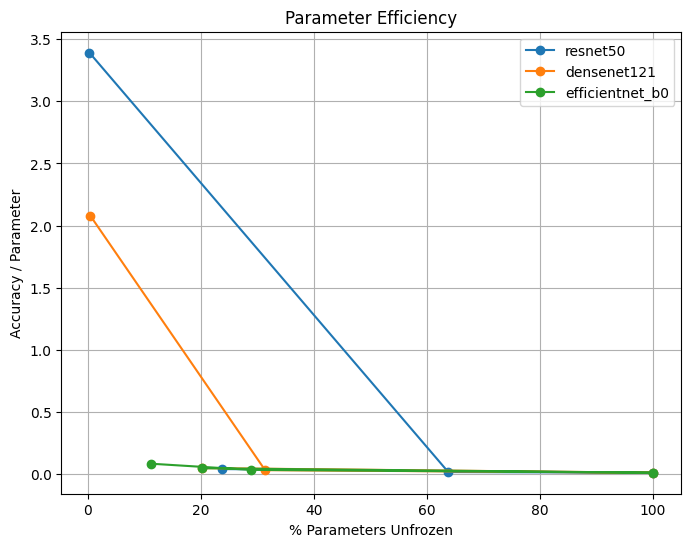

In [ ]:
df["accuracy_per_param"] = df["best_val_acc"] / df["percent_unfrozen"]

plt.figure(figsize=(8,6))

for model in df["model"].unique():

    subset = df[df["model"] == model]

    plt.plot(
        subset["percent_unfrozen"],
        subset["accuracy_per_param"],
        marker='o',
        label=model
    )

plt.xlabel("% Parameters Unfrozen")
plt.ylabel("Accuracy / Parameter")
plt.title("Parameter Efficiency")
plt.legend()
plt.grid(True)
plt.show()

### To analyze parameter efficiency, we evaluated how validation accuracy varies with the percentage of trainable parameters. This helps determine whether tuning more parameters always leads to better performance or whether efficient fine-tuning strategies can achieve comparable results with fewer parameters.

### Linear probing achieves the lowest performance because the pretrained backbone is not adapted to the aerial imagery domain. Fine-tuning deeper layers significantly improves performance, demonstrating that high-level representations must adapt to the new dataset.

Interestingly, full fine-tuning does not always outperform partial fine-tuning. For both ResNet50 and DenseNet121, fine-tuning only the last block yields slightly better performance than updating the entire network.

Selective tuning (~20% parameters) provides a good trade-off between computational cost and accuracy, achieving competitive performance while updating significantly fewer parameters.

### These results demonstrate that careful selection of trainable parameters can achieve strong performance without the need to fine-tune the entire network, highlighting the importance of parameter-efficient transfer learning.

# Model Efficiency Comparison (MACs / FLOPs / Params)

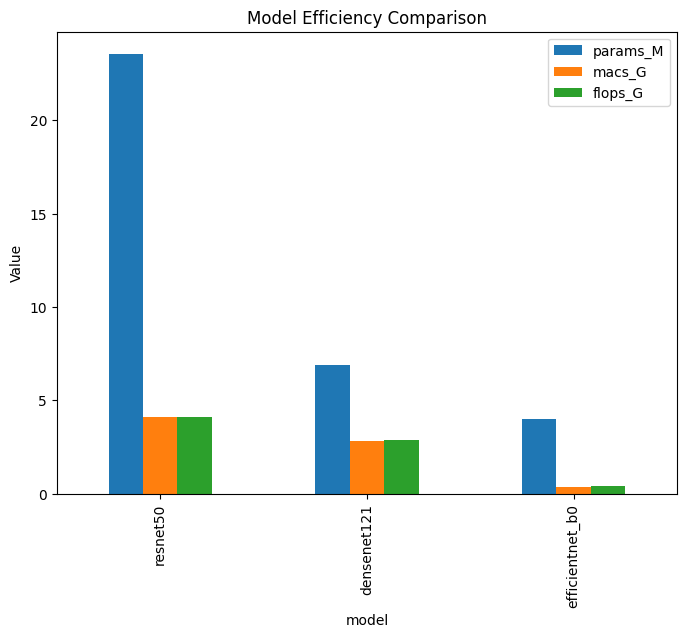

In [ ]:
efficiency = df.drop_duplicates("model")[["model","params_M","macs_G","flops_G"]]

efficiency.plot(
    x="model",
    kind="bar",
    figsize=(8,6)
)

plt.title("Model Efficiency Comparison")
plt.ylabel("Value")
plt.show()

# Bonus Part 2

### Instead of manually selecting layers to fine-tune, we implemented an automated parameter selection strategy that progressively unfreezes deeper layers until a predefined parameter budget (20% of total parameters) is reached.

### The algorithm begins with all backbone layers frozen. Parameters are then unfrozen starting from the deepest layers of the network. The process stops once the number of trainable parameters reaches approximately 20% of the total model parameters.

### This strategy assumes that deeper layers capture task-specific semantic representations, while early layers encode general visual patterns such as edges and textures. By prioritizing deeper layers, the model adapts efficiently to the new dataset while preserving useful pretrained features.

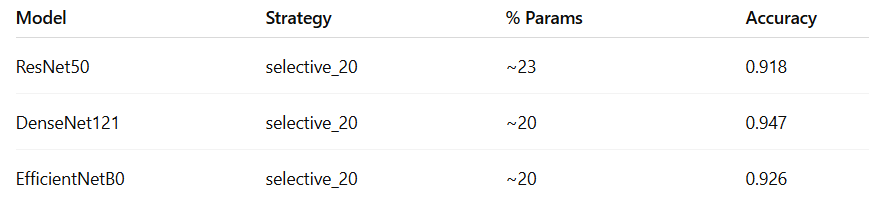

### The automated strategy achieves competitive accuracy while tuning far fewer parameters than full fine-tuning. For example, DenseNet121 achieves 0.947 validation accuracy while tuning only ~20% of parameters, compared to 0.941 when the entire network is trained.

### These results demonstrate that automated parameter selection can significantly reduce computational cost while maintaining strong performance, making it a practical approach for efficient transfer learning.